# Top-k / Context vs. Accuracy analysis

Sweep: `evaluations/sweeps/20260707T032745Z` — 5 memory variants × `top_k ∈ {3, 5, 10, 15}`, n=1000 each.

Two questions:

1. **Does more context help?** `top_k` controls how many items are retrieved, and `query_tokens_total_mean` is the *actual* context size fed to the model. We look at accuracy against both.
2. **How do the variants stack up** against each other, and at what token cost (the project's core efficiency tradeoff).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

SWEEP = Path("../evaluations/sweeps/20260707T032745Z")
df = pd.read_csv(SWEEP / "sweep_summary.csv")
df

,combo_id,variant,top_k,n,accuracy_em,accuracy_judge,f1_mean,query_latency_ms_mean,query_tokens_total_mean
0,bm25_c00,bm25,3,1000,0.331,0.4055,0.4113,413.95,397.01
1,bm25_c01,bm25,5,1000,0.337,0.4310,0.4249,460.86,627.04
2,bm25_c02,bm25,10,1000,0.376,0.4820,0.4848,587.59,1272.02
3,bm25_c03,bm25,15,1000,0.394,0.5000,0.4978,694.02,1937.75
4,vector_c00,vector,3,1000,0.369,0.4520,0.4501,429.36,424.44
5,vector_c01,vector,5,1000,0.389,0.4855,0.4838,464.03,663.37
6,vector_c02,vector,10,1000,0.404,0.5175,0.5142,591.31,1296.49
7,vector_c03,vector,15,1000,0.417,0.5305,0.5286,703.06,1944.39
8,graph_c00,graph,3,1000,0.238,0.2830,0.2839,665.34,121.14
9,graph_c01,graph,5,1000,0.235,0.2715,0.2766,675.78,142.25


In [2]:
# --- Design system: fixed categorical colors per variant (CVD-safe, dataviz skill) ---
# Color follows the entity (variant), never its rank. Order chosen for adjacent separation.
VARIANT_ORDER = ["vector", "vectorgraphtext", "bm25", "graphtext", "graph"]
VARIANT_COLOR = {
    "vector":          "#2a78d6",  # blue
    "vectorgraphtext": "#1baf7a",  # aqua
    "bm25":            "#eda100",  # yellow
    "graphtext":       "#4a3aa7",  # violet
    "graph":           "#e34948",  # red
}
VARIANT_LABEL = {
    "vector": "Vector", "vectorgraphtext": "VectorGraphText", "bm25": "BM25",
    "graphtext": "GraphText", "graph": "Graph",
}

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 120, "savefig.dpi": 120,
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 10,
})

def order_variants(frame):
    return [v for v in VARIANT_ORDER if v in frame["variant"].unique()]

## 1. Does higher `top_k` improve accuracy?

LLM-judge accuracy against `top_k`, one line per variant. This isolates the retrieval-depth knob.

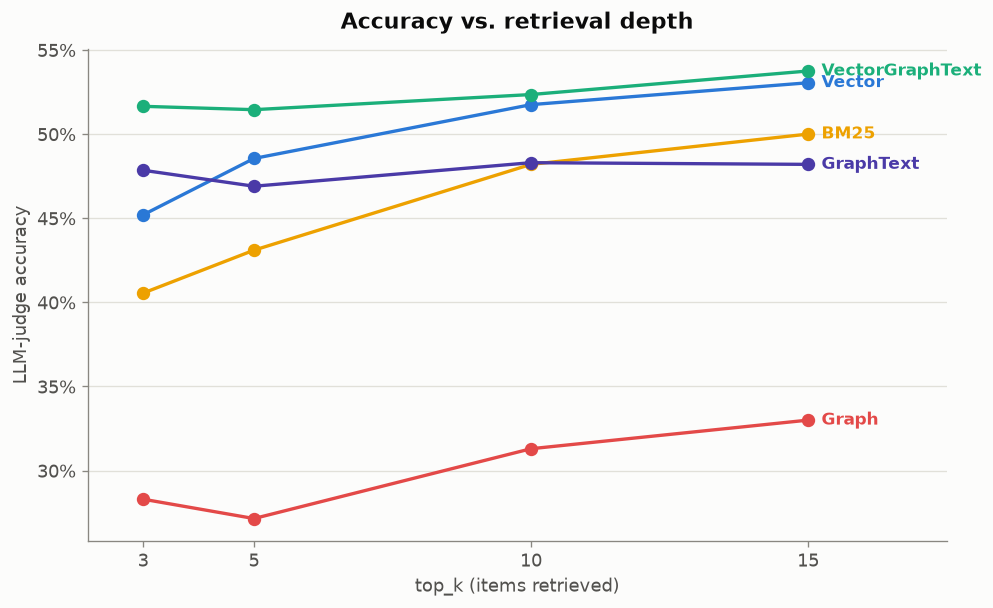

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))

for v in order_variants(df):
    sub = df[df["variant"] == v].sort_values("top_k")
    ax.plot(sub["top_k"], sub["accuracy_judge"], marker="o", markersize=7,
            linewidth=2, color=VARIANT_COLOR[v], label=VARIANT_LABEL[v], zorder=3)
    # direct label at the right end
    last = sub.iloc[-1]
    ax.annotate(VARIANT_LABEL[v], (last["top_k"], last["accuracy_judge"]),
                xytext=(8, 0), textcoords="offset points", va="center",
                color=VARIANT_COLOR[v], fontsize=10, fontweight="bold")

ax.set_xticks(sorted(df["top_k"].unique()))
ax.set_xlim(2, 17.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("top_k (items retrieved)")
ax.set_ylabel("LLM-judge accuracy")
ax.set_title("Accuracy vs. retrieval depth")
fig.tight_layout()
plt.show()

**Read:** for the flat retrievers (Vector, BM25) accuracy climbs monotonically with `top_k`. The graph-native variants (Graph, GraphText, VectorGraphText) are much flatter — they already carry their signal at low `top_k`, so extra depth buys little.

## 2. Accuracy vs. *actual* context size

`top_k` is a proxy; `query_tokens_total_mean` is the real number of context tokens the model consumes. Plotting accuracy against it shows the true accuracy-per-token picture (note the log x-axis — token cost spans an order of magnitude across variants).

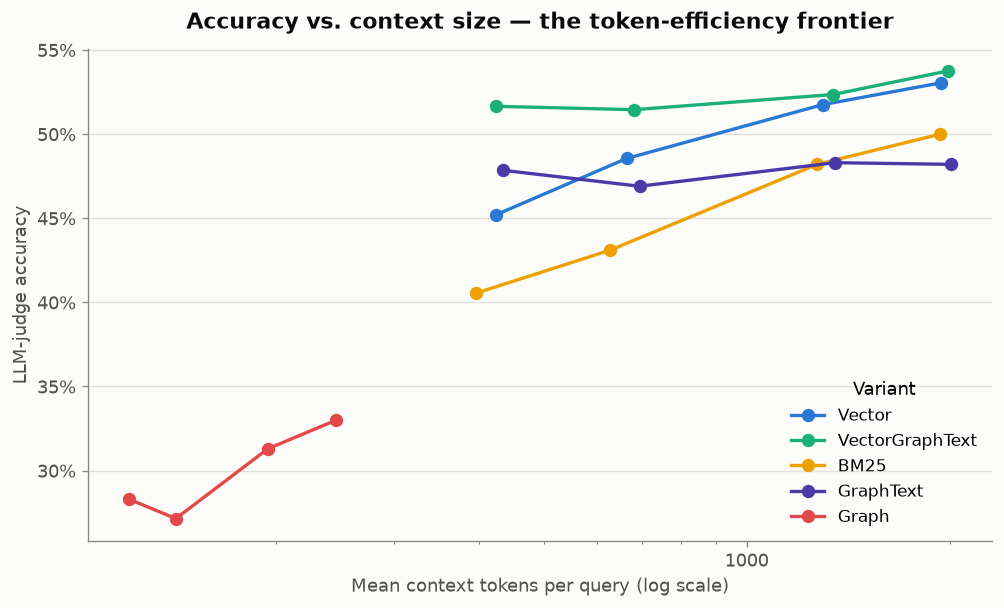

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))

for v in order_variants(df):
    sub = df[df["variant"] == v].sort_values("query_tokens_total_mean")
    ax.plot(sub["query_tokens_total_mean"], sub["accuracy_judge"], marker="o",
            markersize=7, linewidth=2, color=VARIANT_COLOR[v],
            label=VARIANT_LABEL[v], zorder=3)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Mean context tokens per query (log scale)")
ax.set_ylabel("LLM-judge accuracy")
ax.set_title("Accuracy vs. context size — the token-efficiency frontier")
ax.legend(title="Variant", loc="lower right")
fig.tight_layout()
plt.show()

**Read:** a variant sitting up-and-left is more token-efficient (same accuracy, fewer tokens). VectorGraphText reaches the top accuracy band while its curve sits left of plain Vector at matched accuracy. Pure Graph is cheapest per query but caps out well below the others.

## 3. Variant-vs-variant comparison

Heatmap of judge accuracy across every `variant × top_k` cell — the whole grid at a glance.

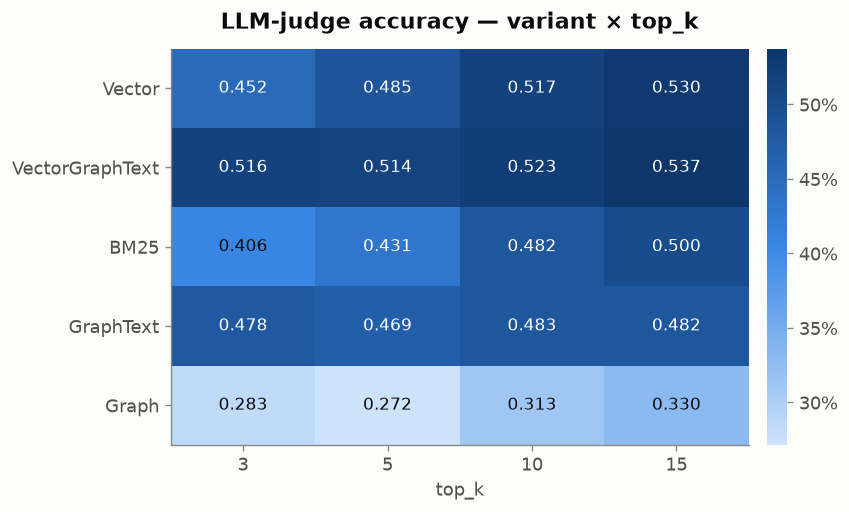

In [5]:
pivot = (df.pivot(index="variant", columns="top_k", values="accuracy_judge")
           .reindex(order_variants(df)))

fig, ax = plt.subplots(figsize=(7.2, 4.4))
# sequential blue ramp (dataviz skill): light = low, dark = high
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#3987e5", "#0d366b"])
im = ax.imshow(pivot.values, cmap=cmap, aspect="auto",
               vmin=df["accuracy_judge"].min(), vmax=df["accuracy_judge"].max())

ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), [VARIANT_LABEL[v] for v in pivot.index])
ax.set_xlabel("top_k")
ax.set_title("LLM-judge accuracy — variant × top_k")
ax.grid(False)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        norm = (val - df["accuracy_judge"].min()) / (df["accuracy_judge"].max() - df["accuracy_judge"].min())
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10,
                color="white" if norm > 0.55 else INK)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.outline.set_visible(False)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
fig.tight_layout()
plt.show()

## 4. Best-case comparison across all three accuracy metrics

Each variant at its own best-judge `top_k`, shown for EM / judge / F1 so the ranking isn't an artifact of one metric.

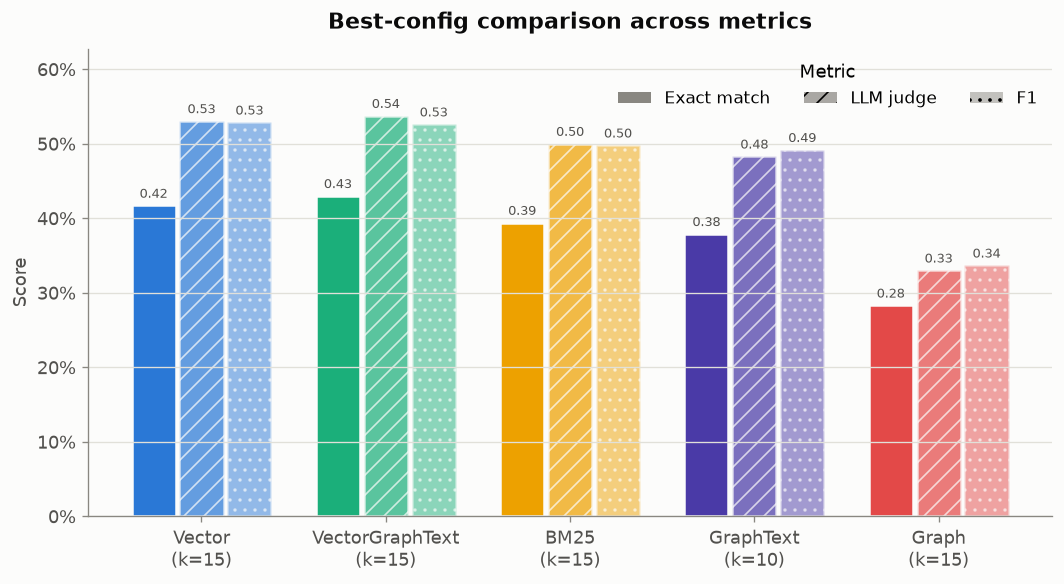

In [6]:
best = (df.sort_values("accuracy_judge")
          .groupby("variant").tail(1).set_index("variant")
          .reindex(order_variants(df)))

metrics = [("accuracy_em", "Exact match"), ("accuracy_judge", "LLM judge"), ("f1_mean", "F1")]
x = np.arange(len(best.index))
w = 0.26
hatches = ["", "//", ".."]

fig, ax = plt.subplots(figsize=(9, 5))
for k, (col, name) in enumerate(metrics):
    bars = ax.bar(x + (k - 1) * w, best[col], width=w * 0.92,
                  color=[VARIANT_COLOR[v] for v in best.index],
                  alpha=[1.0, 0.72, 0.5][k], edgecolor=SURFACE, linewidth=1.5,
                  hatch=hatches[k], label=name)
    for b, val in zip(bars, best[col]):
        ax.text(b.get_x() + b.get_width() / 2, val + 0.006, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8, color=INK2)

ax.set_xticks(x, [f"{VARIANT_LABEL[v]}\n(k={int(best.loc[v, 'top_k'])})" for v in best.index])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("Score")
ax.set_title("Best-config comparison across metrics")
# neutral legend: metric encoded by opacity+hatch, not color (color = variant)
from matplotlib.patches import Patch
handles = [Patch(facecolor=MUTED, alpha=a, hatch=h, label=n)
           for (_, n), a, h in zip(metrics, [1.0, 0.72, 0.5], hatches)]
ax.legend(handles=handles, title="Metric", loc="upper right", ncol=3)
ax.set_ylim(0, best[[m[0] for m in metrics]].max().max() + 0.09)
fig.tight_layout()
plt.show()

## Takeaways

- **Context helps, but with sharply diminishing returns and only for flat retrievers.** Vector and BM25 gain ~6–7 judge points going `top_k` 3→15; the graph-native variants are nearly flat.
- **VectorGraphText is the accuracy leader** across metrics and reaches its ceiling at low `top_k`, giving the best accuracy-per-token position (chart 2).
- **Pure Graph is the token-efficiency extreme** (~120–250 tokens/query) but trades away ~20 accuracy points — the classic ingestion-vs-test-time tradeoff this project exists to measure.
- Adding raw text back onto the graph (`graphtext`, `vectorgraphtext`) recovers most of that lost accuracy at a moderate token cost.